In [ ]:
import rasterio
from rasterio.windows import Window
import matplotlib.pyplot as plt
import numpy as np

# Coordinates - use the ones that worked for you yesterday!
col, row = 0, 0 
w, h = 1000, 1000
my_window = Window(col, row, w, h)
B04_PATH = r"C:\Users\hsgpi\OneDrive\Desktop\S2C_MSIL2A_20260213T045921_N0512_R119_T44QQE_20260213T133817.SAFE\GRANULE\L2A_T44QQE_A007525_20260213T051019\IMG_DATA\R10m\B04_10m.jp2"
B08_PATH = r"C:\Users\hsgpi\OneDrive\Desktop\S2C_MSIL2A_20260213T045921_N0512_R119_T44QQE_20260213T133817.SAFE\GRANULE\L2A_T44QQE_A007525_20260213T051019\IMG_DATA\R10m\B08_10m.jp2"

with rasterio.open(B04_PATH) as red_src, \
     rasterio.open(B08_PATH) as nir_src:
    
    red_raw = red_src.read(1, window=my_window).astype(np.float32)
    nir_raw = nir_src.read(1, window=my_window).astype(np.float32)

    bands = [red_raw, nir_raw]
    names = ['Red Band (B04)', 'NIR Band (B08)']

    for i in range(2):
        haze=np.min(bands[i][bands[i]>0])

        corrected = bands[i] - haze
        print(f"the haze value for {names[i]} is: {haze}")


    # Plotting them together
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))
    
    # Red Band
    im1=ax1.imshow(red_raw, cmap='Reds_r') # Red band is usually darker, so we keep default vmax
    ax1.set_title("Red Band (B04) - 'Food' for plants")
    cbar1=fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
    cbar1.set_label("Reflectance intensity", rotation=270, labelpad=10)
    
    # NIR Band
    im2=ax2.imshow(nir_raw, cmap='Greens') # NIR is usually brighter, so we increase vmax
    ax2.set_title("NIR Band (B08) - 'Heat' reflected by plants")
    cbar2=fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
    cbar2.set_label("Reflectance intensity", rotation=270, labelpad=15)
    
    plt.show()

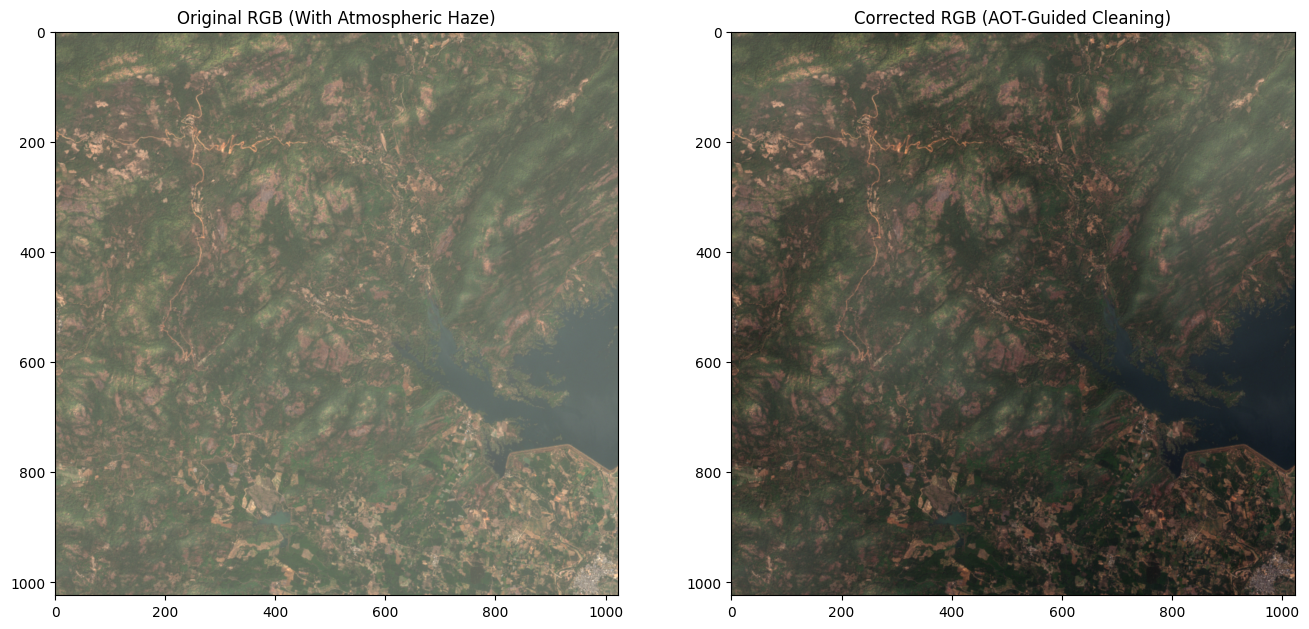

🎉 Success! Your atmospherically corrected image is saved as: Sentinel2_Corrected_RGB.jpg


In [32]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from rasterio.windows import Window

# 1. Your paths and setup
file_paths = [
    r"C:\Users\hsgpi\OneDrive\Desktop\S2C_MSIL2A_20260213T045921_N0512_R119_T44QQE_20260213T133817.SAFE\GRANULE\L2A_T44QQE_A007525_20260213T051019\IMG_DATA\R10m\B04_10m.jp2",
    r"C:\Users\hsgpi\OneDrive\Desktop\S2C_MSIL2A_20260213T045921_N0512_R119_T44QQE_20260213T133817.SAFE\GRANULE\L2A_T44QQE_A007525_20260213T051019\IMG_DATA\R10m\B03_10m.jp2",
    r"C:\Users\hsgpi\OneDrive\Desktop\S2C_MSIL2A_20260213T045921_N0512_R119_T44QQE_20260213T133817.SAFE\GRANULE\L2A_T44QQE_A007525_20260213T051019\IMG_DATA\R10m\B02_10m.jp2",
    r"C:\Users\hsgpi\OneDrive\Desktop\S2C_MSIL2A_20260213T045921_N0512_R119_T44QQE_20260213T133817.SAFE\GRANULE\L2A_T44QQE_A007525_20260213T051019\IMG_DATA\R10m\B08_10m.jp2", 
    r"C:\Users\hsgpi\OneDrive\Desktop\S2C_MSIL2A_20260213T045921_N0512_R119_T44QQE_20260213T133817.SAFE\GRANULE\L2A_T44QQE_A007525_20260213T051019\IMG_DATA\R10m\AOT_10m.jp2"
]
my_window = Window(0, 0, 1024, 1024)

data_list = []
for path in file_paths:
    with rasterio.open(path) as src:
        band = src.read(1, window=my_window).astype(np.float32) / 10000
        data_list.append(band)

stack = np.stack(data_list)
aot_map = stack[4] # This is our 'Haze Guide'

# --- THE HAZE FIX ---
# 1. We determine how much each pixel's haze contributes.
# We normalize the AOT map so the clearest pixel is 0 and the haziest is 1
aot_weight = (aot_map - np.min(aot_map)) / (np.max(aot_map) - np.min(aot_map))

# 2. Apply correction to R, G, and B bands (Indices 0, 1, 2)
# We subtract a base haze (min value) but multiply it by the AOT weight
corrected_bands = []
for i in range(3):
    base_haze = np.min(stack[i][stack[i] > 0])
    # The fix: Subtract more where AOT is higher
    fixed = stack[i] - (base_haze * aot_weight)
    corrected_bands.append(np.clip(fixed, 0, 1))

# 3. Create the 'Clean' RGB image
rgb_clean = np.dstack((corrected_bands[0], corrected_bands[1], corrected_bands[2]))
rgb_clean_enhanced = np.clip(rgb_clean * 3, 0, 1)

# --- VISUALIZE BEFORE vs AFTER ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

ax1.imshow(np.clip(np.dstack((stack[0], stack[1], stack[2])) * 3, 0, 1))
ax1.set_title("Original RGB (With Atmospheric Haze)")

ax2.imshow(rgb_clean_enhanced)
ax2.set_title("Corrected RGB (AOT-Guided Cleaning)")

plt.show()
# 1. Choose a filename
output_filename = "Sentinel2_Corrected_RGB.jpg"

# 2. Save the enhanced image
# We use 'bbox_inches=tight' to remove white margins
plt.imsave(output_filename, rgb_clean_enhanced)

print(f"🎉 Success! Your atmospherically corrected image is saved as: {output_filename}")